In [187]:
import numpy as np
import pandas as pd
import cv2
import os
from pathlib import Path
from collections import Counter

import torch
from keras.src.saving import load_model
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Layer, BatchNormalization, Activation
from keras.src.models import Sequential


from keras.src.callbacks import EarlyStopping, ModelCheckpoint
#from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.preprocessing.image import load_img
from keras.src.legacy.preprocessing.image import ImageDataGenerator


import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

import warnings



warnings.filterwarnings('ignore')

In [188]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device.type}")

Using device: cpu


In [189]:
def check_folder(data_path):
    """
    Функция возвращает данные о содержимом папки
    :param data_path: folder path
    """
    folder = Path(data_path)
    
    total_files = 0
    total_folders = 0
    total_size = 0
    extensions = []
    
    for item in folder.rglob('*'):  # рекурсивно пройдем по всем вложенным файлам и папкам
        if item.is_file():
            total_files += 1
            total_size += item.stat().st_size
            ext = item.suffix.lower() if item.suffix else 'без расширения'
            extensions.append(ext)
        elif item.is_dir():
            total_folders += 1
    
    ext_counts = Counter(extensions)
    
    folder_stats = (total_files, total_folders, total_size)
    
    print(f"Статистика папки: {data_path}")
    print(f"Всего файлов: {total_files}")
    print(f"Всего папок (включая вложенные): {total_folders}")
    print(f"Общий размер файлов: {total_size / (1024**2):.2f} МБ")
    print("\nРаспределение по расширениям файлов:")
    for ext, count in ext_counts.most_common():
        print(f"  {ext}: {count}")
    return folder_stats

In [190]:
data_path = os.path.join(str(Path.home()), 'PycharmProjects/ML/src/data', 'animals')
if not os.path.exists(data_path):
    os.makedirs(data_path)

в этот раз, для разнообразия, используем для загрузки данных API. Короткая напоминалка, чтобы всё получилось:
1. Создайте (или скачайте) файл `kaggle.json`
	* Перейдите в ваш аккаунт Kaggle: https://www.kaggle.com/
	* Нажмите на ваш профиль → “Account” (Аккаунт)
	* В разделе “API” нажмите “Create New API Token” 
2. Поместите файл `kaggle.json` в нужное место
	* Переместите скачанный файл в папку /Users/aleksandrkoval/.kaggle/
3. Задать нужные права на файл
    * chmod 600 kaggle.json

In [191]:
from kaggle.api.kaggle_api_extended import KaggleApi

folder_stats = check_folder(data_path)
if folder_stats[2] == 0:
    api = KaggleApi()
    api.authenticate()
    api.dataset_download_files("andrewmvd/animal-faces", path=data_path, unzip=True)
    print("\nЗагрузка завершена")
else:  print("\nПапка не пустая")

Статистика папки: /Users/aleksandrkoval/PycharmProjects/ML/src/data/animals
Всего файлов: 16134
Всего папок (включая вложенные): 9
Общий размер файлов: 695.59 МБ

Распределение по расширениям файлов:
  .jpg: 16130
  без расширения: 4

Папка не пустая


In [203]:
data_train = os.path.join(data_path, 'afhq/train/')
data_test = os.path.join(data_path, 'afhq/val/')

In [204]:
def get_animals_data(classes, data_path):
    """
    возвращает DataFrame, содержащий путь к картинке и класс животного
    :param classes: classes of animals
    :param data_path: path of data
    """
    allPics = []
    allAnimals = []
    for classElement in classes:
        filenames = os.listdir(os.path.join(data_path, classElement))
        for file in filenames:
            file_name = os.path.join(classElement, file)
            allPics.append(file_name)
        allAnimals.extend([classes[classElement]] * len(filenames))
    
    df = pd.DataFrame({
        'filename': allPics,
        'class': allAnimals
    })
    return df

In [205]:
classes = {"cat": "0", "dog": "1", "wild": "2"}
df_train = get_animals_data(classes, data_train)
df_test = get_animals_data(classes, data_test)
print("df_test:", df_test.shape) 
display(df_test.head())

df_test: (1500, 2)


,filename,class
0,cat/pixabay_cat_002256.jpg,0
1,cat/pixabay_cat_000441.jpg,0
2,cat/flickr_cat_000802.jpg,0
3,cat/flickr_cat_000816.jpg,0
4,cat/flickr_cat_000180.jpg,0


In [206]:
def show_images(path, df, title="Image", cols=3, cmap=None):
    """
    выводит заданное количество картинок для каждого класса животных
    :param path: path to folder
    :param df: dataframe
    :param title: title
    :param cols: number of pics to show
    :param cmap: color map
    """
    filter_val = []
    filter_val = df.groupby('class').head(cols)
    img_list = list(os.path.join(path,filename) for filename in filter_val['filename'].to_list())
    print(len(img_list))
    plt.figure(figsize=(cols*3, cols*9/5), dpi=300)
    if cols*3 > len(img_list): cols = len(img_list)
    for i, img_p in enumerate(img_list):
        plt.subplot(1, cols*3, i+1)
        img = cv2.imread(img_p)
        if len(img.shape) == 2:
            plt.imshow(img, cmap=cmap or "gray")
        else:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.title(f"{title} {i+1}")
        #if i == cols*3 - 1: break
    plt.show()

12


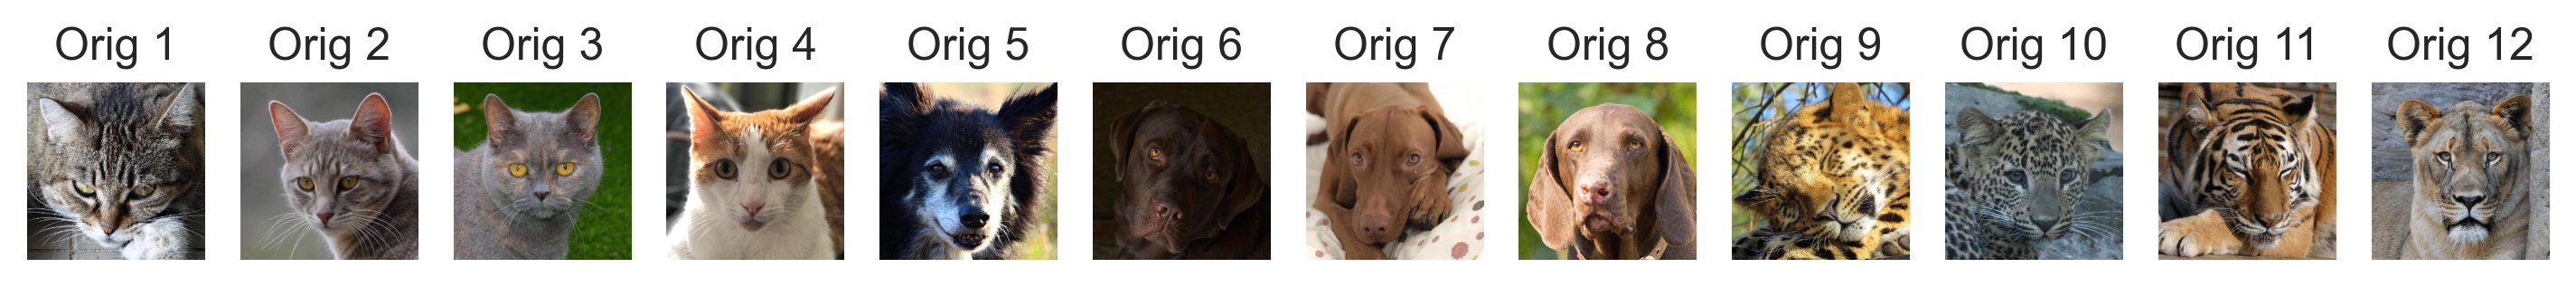

In [207]:
show_images(data_test, df_test, "Orig", 4) 
# путь, датафрейм, подпись, количество картинок из каждого вида

12


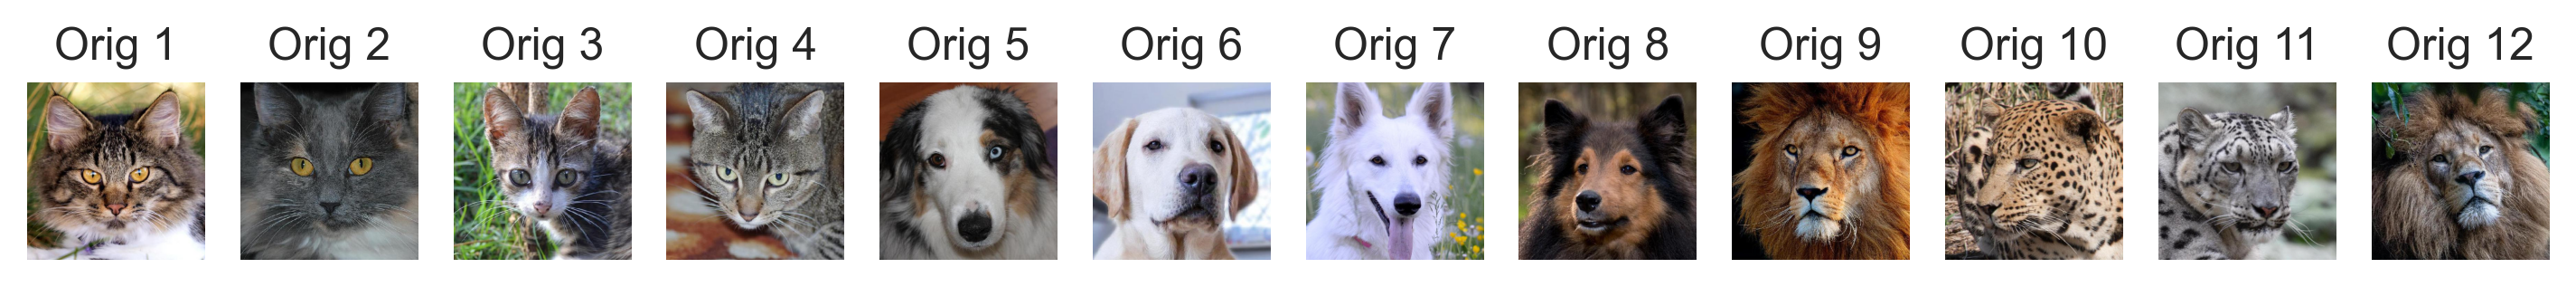

In [208]:
show_images(data_train, df_train, "Orig", 4)

Подготовка данных

In [209]:
df_training, df_testing = train_test_split(df_train, test_size = 0.20)
df_training = df_training.reset_index(drop = True)
df_testing = df_testing.reset_index(drop = True)

In [210]:
df_training[:5]

,filename,class
0,cat/pixabay_cat_000135.jpg,0
1,cat/pixabay_cat_000539.jpg,0
2,cat/pixabay_cat_000058.jpg,0
3,wild/pixabay_wild_000081.jpg,2
4,cat/pixabay_cat_003561.jpg,0


In [217]:
df_testing[:5]

,filename,class
0,cat/pixabay_cat_001660.jpg,0
1,dog/pixabay_dog_000907.jpg,1
2,dog/pixabay_dog_000785.jpg,1
3,wild/flickr_wild_001887.jpg,2
4,wild/flickr_wild_003699.jpg,2


Расширение обучающих данных:
* Диапазон поворота: 20°
* Диапазон изменения ширины/высоты: 0,2
* Диапазон сдвига: 0,2
* Диапазон масштабирования: 0,2
* Горизонтальный сдвиг: включен
* Режим заливки: Ближайший сосед

In [211]:
IMG_SIZE = 150
batch_size = 64

In [212]:
cnn_train_datagen = ImageDataGenerator(
    rotation_range = 45,
    width_shift_range = 0.2,  
    height_shift_range = 0.2,    
    zoom_range = 0.2,        
    horizontal_flip = True, 
    rescale = 1./255,
    validation_split=0.2,
    fill_mode = 'nearest'
)

cnn_test_datagen = ImageDataGenerator(
    rescale = 1./255,
)

In [219]:
cnn_train_generator = cnn_train_datagen.flow_from_dataframe(
        dataframe=df_training,
        directory = data_train,
        target_size=(IMG_SIZE,IMG_SIZE),
        x_col = 'filename',
        y_col = 'class',
        batch_size=batch_size,
        class_mode='categorical',
        subset='training'
)

cnn_test_generator = cnn_test_datagen.flow_from_dataframe(
        dataframe=df_testing,
        directory = data_train,
        target_size=(IMG_SIZE,IMG_SIZE),
        x_col = 'filename',
        y_col = 'class',
        batch_size=batch_size,
        class_mode='categorical',
        subset='training'
)

Found 9364 validated image filenames belonging to 3 classes.
Found 2926 validated image filenames belonging to 3 classes.


Found 1 validated image filenames belonging to 1 classes.


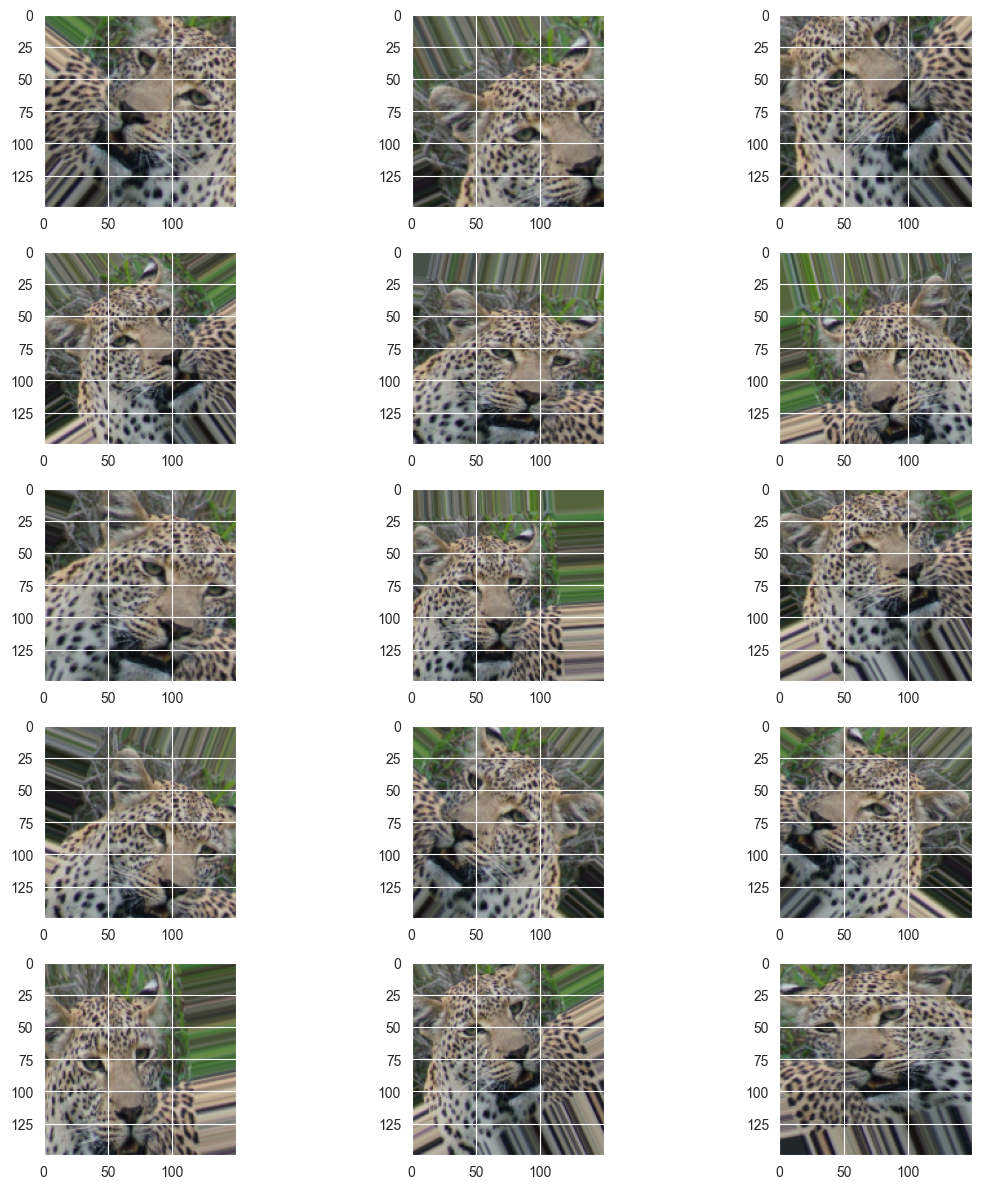

In [168]:
# посмотрим, как будет выглядеть преобразование изображений на одном примере

df_example = df_training.sample(n=1).reset_index(drop=True)
example_generator = cnn_train_datagen.flow_from_dataframe(
    dataframe= df_example, 
    directory= data_train, 
    x_col='filename',
    y_col='class',
    target_size = (IMG_SIZE,IMG_SIZE),
    class_mode='categorical',
    subset='training'
)

plt.figure(figsize=(12, 12))
for i in range(0, 15):
    plt.subplot(5, 3, i+1)
    for X_batch, Y_batch in example_generator:
        image = X_batch[0]
        plt.imshow(image)
        break
plt.tight_layout()
plt.show()

In [169]:
cnn_train_generator.class_indices

{'0': 0, '1': 1, '2': 2}

 запустим несколько последовательных слоёв с последовательным увеличением количества фильтров 32-64-128-256-256-512. Это обеспечивает последовательное обучение более абстрактных блоков, начиная с более простых.

In [170]:
def conv_block(x, filters, kernel_size=(3,3), dropout_rate=0.1):
    x = Conv2D(filters, kernel_size, padding='same',
               kernel_regularizer=regularizers.l2(1e-4))(x)
    x = BatchNormalization()(x) # нормализация активаций в батче для ускорения и стабилизации обучения. 
    x = Activation('relu')(x) 
    x = MaxPooling2D((2,2))(x) # операция подвыборки, уменьшает размерность карты признаков в 2 раза по ширине и высоте
    x = Dropout(dropout_rate)(x) # регуляризация, случайно исключаем 20% нейронов для предотвращения переобучения. 
    return x

In [171]:
def create_cnn_model(input_shape, num_classes):
    inputs = keras.layers.Input(shape=input_shape) # первый слой на входе сети
    
    x = conv_block(inputs, 32) #свёрточный слой, извлекающий признаки из изображения
    x = conv_block(x, 64)
#    x = conv_block(x, 64)
    x = conv_block(x, 128)
    x = conv_block(x, 128)
    x = conv_block(x, 256)
    x = conv_block(x, 256)
    x = conv_block(x, 512)
 #   x = conv_block(x, 512)
#    x = conv_block(x, 1024)
    
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.3)(x)  # регуляризация, случайно исключаем 50% нейронов для предотвращения переобучения. 
    x = keras.layers.Dense(256, activation='relu',
                  kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = keras.layers.Dropout(0.2)(x)
    x = keras.layers.BatchNormalization()(x)
    outputs = keras.layers.Dense(num_classes, activation='softmax')(x)
    model = keras.models.Model(inputs, outputs)
    return model

In [172]:
num_classes = len(cnn_test_generator.class_indices)  # сколько у вас классов
input_shape = (IMG_SIZE, IMG_SIZE, 3)

In [173]:
# Создаём модель
cnn_model = create_cnn_model(input_shape, num_classes)

In [174]:
# Компилируем модель
cnn_model.compile(
    optimizer=keras.optimizers.Adam(),  
    loss='categorical_crossentropy',
    metrics=['accuracy',tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

In [175]:
cnn_model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_43 (Activation)      │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_55 (Dropout)            │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_44 (Activation)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_56 (Dropout)            │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_45 (Activation)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_57 (Dropout)            │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_52          │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_46 (Activation)      │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_58 (Dropout)            │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 9, 9, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_53          │ (None, 9, 9, 256)      │         1,02

 Total params: 2,444,867 (9.33 MB)

 Trainable params: 2,441,603 (9.31 MB)

 Non-trainable params: 3,264 (12.75 KB)

In [176]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        filepath='best_weights.h5',
        monitor='val_loss',
        save_best_only=False,
        save_weights_only=False,
        mode='min',
        verbose=1
    )
]
cnn_history = cnn_model.fit(
        cnn_train_generator,
        epochs = 10,
        validation_data = cnn_test_generator,
#        callbacks = callbacks
        )

cnn_model.save('best_model.h5')

Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 98s 654ms/step - accuracy: 0.5808 - loss: 1.0574 - precision_3: 0.6190 - recall_3: 0.5048 - val_accuracy: 0.3563 - val_loss: 1.7158 - val_precision_3: 0.3564 - val_recall_3: 0.3563
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 96s 654ms/step - accuracy: 0.7903 - loss: 0.6609 - precision_3: 0.8100 - recall_3: 0.7630 - val_accuracy: 0.3913 - val_loss: 1.5455 - val_precision_3: 0.3956 - val_recall_3: 0.3802
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 96s 650ms/step - accuracy: 0.8644 - loss: 0.4934 - precision_3: 0.8771 - recall_3: 0.8503 - val_accuracy: 0.7565 - val_loss: 0.6729 - val_precision_3: 0.7896 - val_recall_3: 0.7168
Epoch 4/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 95s 643ms/step - accuracy: 0.9004 - loss: 0.4068 - precision_3: 0.9093 - recall_3: 0.8912 - val_accuracy: 0.6296 - val_loss: 1.1944 - val_precision_3: 0.6416 - val_recall_3: 0.6224
Epoch 5/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 95s 647ms/step - accuracy: 0.9184 - loss: 0.3608 - precision_3: 0.9270 - rec

In [182]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
import keras
print("Keras version:", keras.__version__)


TensorFlow version: 2.19.0
Keras version: 3.11.1


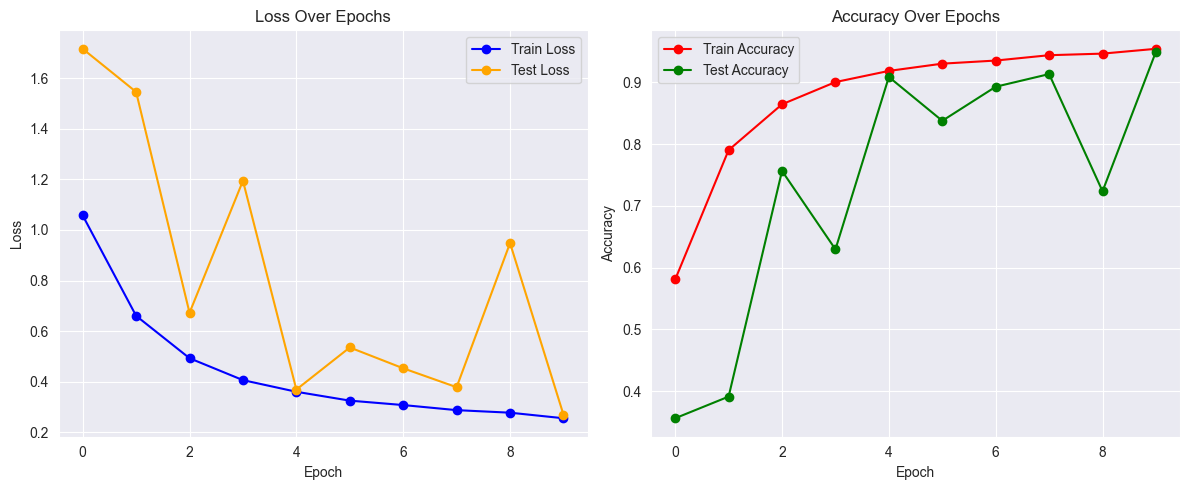

In [183]:
# Plotting training and validation loss and accuracy
plt.figure(figsize=(12, 5))

# 📉 Loss
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['loss'], label='Train Loss', marker='o', color='blue')
plt.plot(cnn_history.history['val_loss'], label='Test Loss', marker='o', color='orange')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# 📈 Accuracy
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['accuracy'], label='Train Accuracy', marker='o', color='red')
plt.plot(cnn_history.history['val_accuracy'], label='Test Accuracy', marker='o', color='green')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [184]:
cnn_model.save('CNN_best_model.keras')

In [185]:
best_model=load_model('CNN_best_model.keras')

Test Loss: 0.2748
Test Accuracy: 0.9509
Test Precision: 0.9556
Test Recall: 0.9470


<Figure size 1000x800 with 0 Axes>

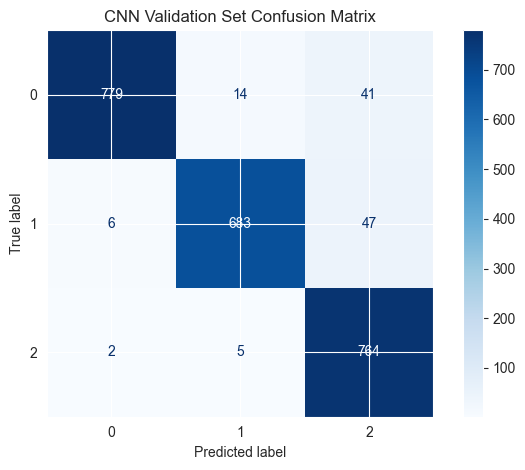


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.93      0.96       834
           1       0.97      0.93      0.95       736
           2       0.90      0.99      0.94       771

    accuracy                           0.95      2341
   macro avg       0.95      0.95      0.95      2341
weighted avg       0.95      0.95      0.95      2341



In [186]:
test_loss, test_accuracy, test_precision, test_recall = best_model.evaluate(
    cnn_test_generator,
    verbose=0
)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")


def get_true_and_pred_labels(generator, model):
    generator.reset()
    y_true = []
    y_pred = []
    
    for i in range(len(generator)):
        x, y = generator[i]
        y_true.extend(np.argmax(y, axis=1)) 
        y_pred.extend(np.argmax(model.predict(x, verbose=0), axis=1))
        
    return np.array(y_true), np.array(y_pred)

y_true, y_pred_classes = get_true_and_pred_labels(cnn_test_generator, best_model)

class_names = list(cnn_test_generator.class_indices.keys())  

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names  
)
disp.plot(cmap='Blues', values_format='d')
plt.title('CNN Validation Set Confusion Matrix')
plt.tight_layout()
plt.show()

report = classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names 
)
print("\nClassification Report:")
print(report)

In [221]:
test_gen = ImageDataGenerator(rescale = 1./255)
test_generator = test_gen.flow_from_dataframe(
    df_test, 
    data_test, 
    x_col='filename',
    y_col=None,
    class_mode= None,
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size = batch_size,
    shuffle = False
)

Found 1500 validated image filenames.


In [224]:
predict = best_model.predict(test_generator, steps = int(np.ceil(df_test.shape[0] / batch_size)))

24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step


In [226]:
df_test['prediction'] = np.argmax(predict, axis=-1)
label_map = dict((v,k) for k,v in cnn_train_generator.class_indices.items())
df_test['prediction'] = df_test['prediction'].replace(label_map)
df_test['prediction'] = df_test['prediction'].replace({ '1': 1, '0': 0 })

In [228]:
df_test['correctPred'] = df_test.apply(lambda x: str(x['class']) == str(x['prediction']), axis=1)

In [246]:
df_test[:5]

,filename,class,prediction,correctPred
0,cat/pixabay_cat_002256.jpg,0,0,True
1,cat/pixabay_cat_000441.jpg,0,0,True
2,cat/flickr_cat_000802.jpg,0,0,True
3,cat/flickr_cat_000816.jpg,0,0,True
4,cat/flickr_cat_000180.jpg,0,0,True


In [265]:
# Подсчет количества True/False в столбце correctPred
counts = df_test['correctPred'].value_counts()

# Создаем датафрейм с этими данными
data = pd.DataFrame({
    'prediction': counts.index,
    'count': counts.values
})

# Строим sunburst
fig = px.pie(data, names='prediction', values='count', title='Correct prediction vs False prediction')
fig.show()

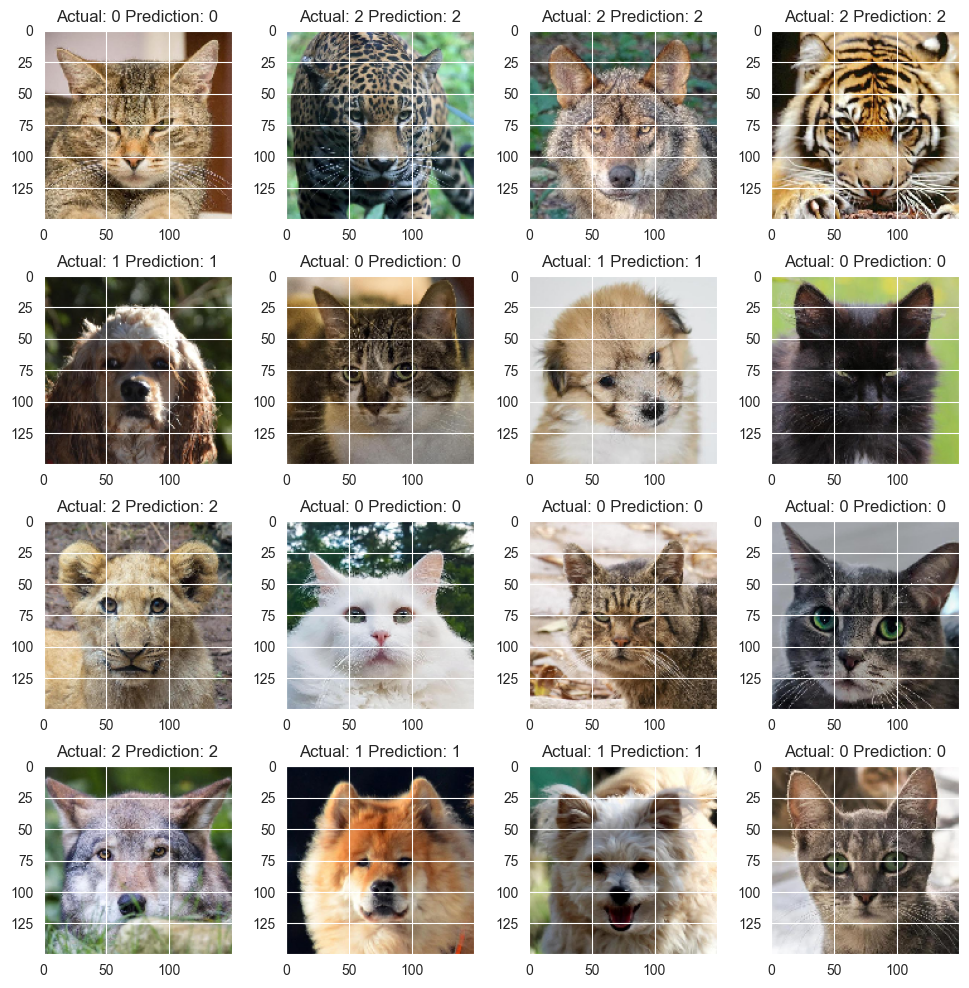

In [244]:
import random
randomlist = []
for i in range(0,16):
    n = random.randint(0,len(df_test))
    randomlist.append(n)

fig = plt.figure(figsize = (12,12))
gs1 = gridspec.GridSpec(4, 4)
axs = []
for num in range(len(randomlist)):
    row = df_test.iloc[[randomlist[num]]]
    filename = row['filename'][randomlist[num]]
    img = load_img(os.path.join(data_test, filename), target_size=(IMG_SIZE, IMG_SIZE))
    axs.append(fig.add_subplot(gs1[num - 1]))
    axs[-1].imshow(img)
    axs[-1].set_title("Actual: " + df_test[df_test["filename"] == filename]["class"].iloc[0] + " Prediction: " + str(row['prediction'][randomlist[num]]) )
fig.subplots_adjust(hspace=0.3)
plt.show()